In [1]:
import xarray as xr
import netCDF4 as nc
import numpy as np
import sys
import os 
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patches as patches
import matplotlib.animation as animation


In [2]:
ds_idealized_100d= xr.open_dataset('../snap_idealized_100d.cdf')
ds_hourly = xr.open_dataset('../snap_hourly.cdf')
ds_hourly_deep = xr.open_dataset('../snap_hourly_deep.cdf')
ds_hourly_highres = xr.open_dataset('../snap_hourly_highres.cdf')

FileNotFoundError: [Errno 2] No such file or directory: '/work/uo0780/u241366/projects/ps3D/tide1/snap_hourly_highres.cdf'

In [2]:
ds = xr.open_dataset('../snap.cdf')

In [5]:
def create_animation_for_dataset(dataset, dataset_name, save_animation=True, z_level=0):
    """Create animation for a single dataset"""
    
    variables = ['u', 'v', 'w', 'p']
    
    # Get time levels from the dataset
    t_levels = None
    for var in variables:
        if var in dataset:
            t_levels = dataset[var].shape[0]
            break
    
    if t_levels is None:
        print(f"Error: No valid variables found in dataset {dataset_name}")
        return None, None
    
    # Compute color limits per variable across all levels and times for this dataset
    color_limits = {}
    for var in variables:
        if var in dataset:
            data_all = dataset[var][:t_levels, z_level, :, :]  # shape (t, y, x)
            color_limits[var] = (np.nanmin(data_all), np.nanmax(data_all))
        else:
            print(f"Warning: Variable {var} not found in dataset {dataset_name}")
            color_limits[var] = (0, 1)  # fallback
    
    # Create figure and subplots
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axes = axs.ravel()
    images = []
    
    # Initialize plots
    for ax, var in zip(axes, variables):
        if var in dataset:
            data = dataset[var][0, z_level, :, :]
            vmin, vmax = color_limits[var]
            
            # Choose appropriate colormap based on variable
            if var in ['u', 'v']:  # velocity components
                cmap = 'RdBu_r'
            elif var == 'w':  # vertical velocity
                cmap = 'seismic'
            else:  # pressure or other
                cmap = 'viridis'
                
            im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, 
                          aspect='auto', origin='lower')
            ax.set_title(f'{var} ({dataset_name})', fontsize=12, fontweight='bold')
            ax.set_xlabel('x (grid points)')
            ax.set_ylabel('y (grid points)')
            
            # Add colorbar
            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=8)
            
        else:
            # Handle missing variable
            im = ax.imshow(np.zeros((10, 10)), cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'{var} (NOT AVAILABLE)', fontsize=12, color='red')
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, 
                   ha='center', va='center', fontsize=20, color='red')
            
        images.append(im)
    
    fig.suptitle(f'Dataset: {dataset_name} - Time step: 0', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    
    def update(frame):
        """Update function for animation"""
        updated_artists = []
        for i, var in enumerate(variables):
            if var in dataset:
                data = dataset[var][frame, z_level, :, :]
                images[i].set_data(data)
                updated_artists.append(images[i])
        
        fig.suptitle(f'Dataset: {dataset_name} - Time step: {frame}', 
                    fontsize=16, fontweight='bold')
        return updated_artists
    
    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=t_levels, 
                                 interval=300, blit=False, repeat=True)
    
    if save_animation:
        # Create output directory
        output_dir = 'fig_idealized'
        os.makedirs(output_dir, exist_ok=True)
        """
        # Save as GIF (optional - requires pillow or imagemagick)
        try:
            gif_filename = os.path.join(output_dir, f'animation_{dataset_name}.gif')
            ani.save(gif_filename, writer='pillow', fps=3)
            print(f"Saved GIF animation: {gif_filename}")
        except Exception as e:
            print(f"Could not save GIF for {dataset_name}: {e}")
        """
        # Save as MP4 (optional - requires ffmpeg)
        try:
            mp4_filename = os.path.join(output_dir, f'animation_{dataset_name}_z={z_level}.mp4')
            ani.save(mp4_filename, writer='ffmpeg', fps=3, bitrate=1800)
            print(f"Saved MP4 animation: {mp4_filename}")
        except Exception as e:
            print(f"Could not save MP4 for {dataset_name}: {e}")
    
    return ani, fig

In [ ]:
create_animation_for_dataset(ds, 'hourly_deep_20d', z_level=149)

In [ ]:
create_animation_for_dataset(ds, 'hourly_deep_20d', z_level=49)

Saved MP4 animation: fig_idealized/animation_hourly_output_10d_z=0.mp4


(<matplotlib.animation.FuncAnimation at 0x7fff915bb620>,
 <Figure size 1400x1000 with 8 Axes>)

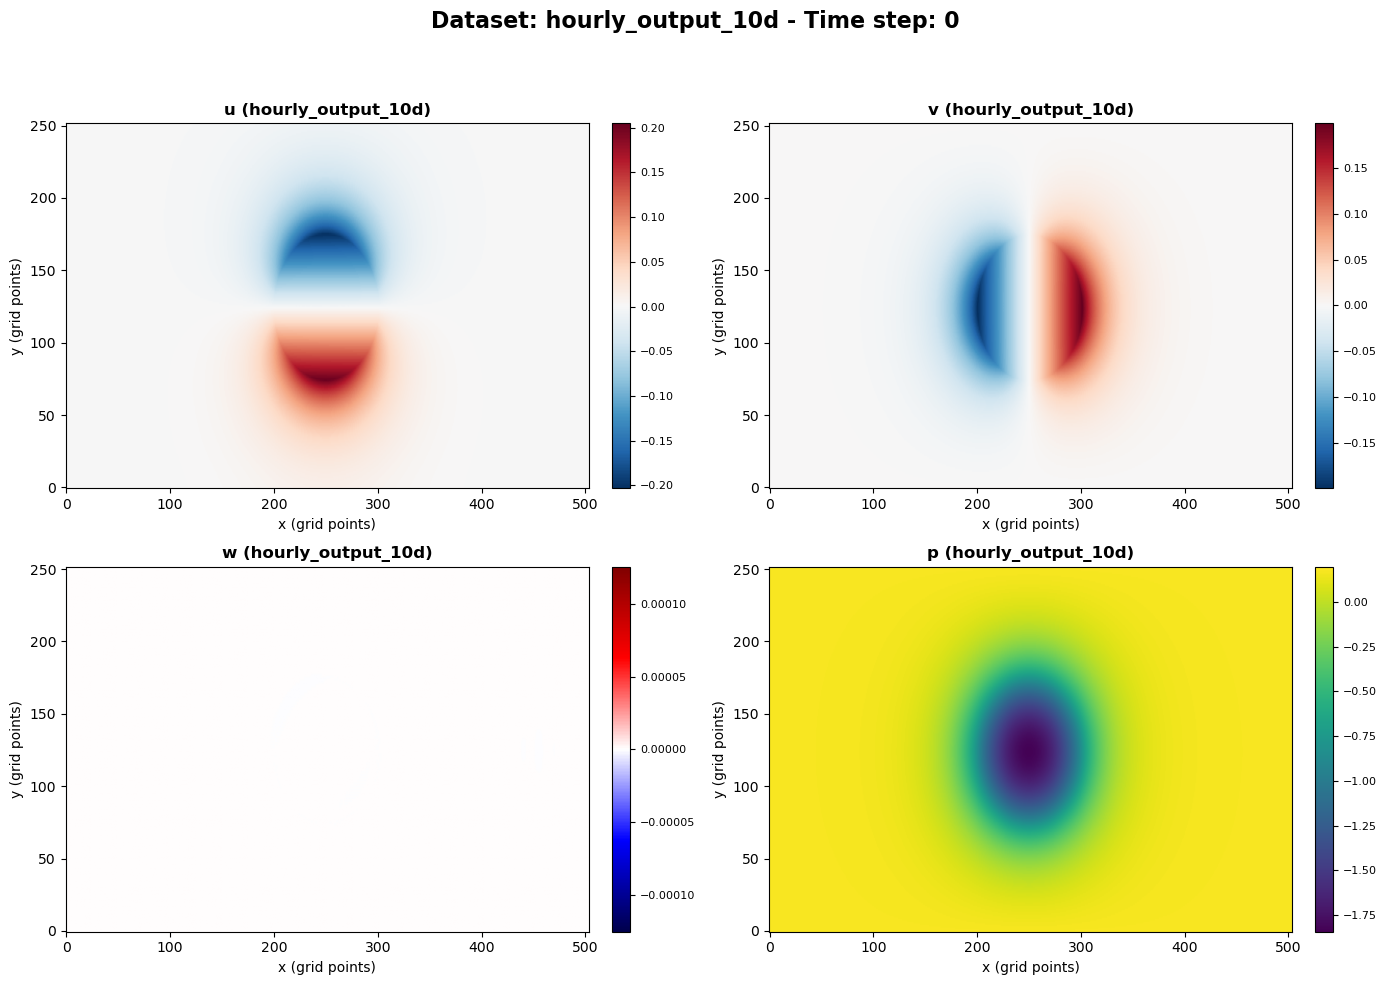

In [26]:
create_animation_for_dataset(ds_hourly, 'hourly_output_10d', z_level=0)

Saved MP4 animation: fig_idealized/animation_hourly_output_highres_z=0.mp4


(<matplotlib.animation.FuncAnimation at 0x7fff98fbca40>,
 <Figure size 1400x1000 with 8 Axes>)

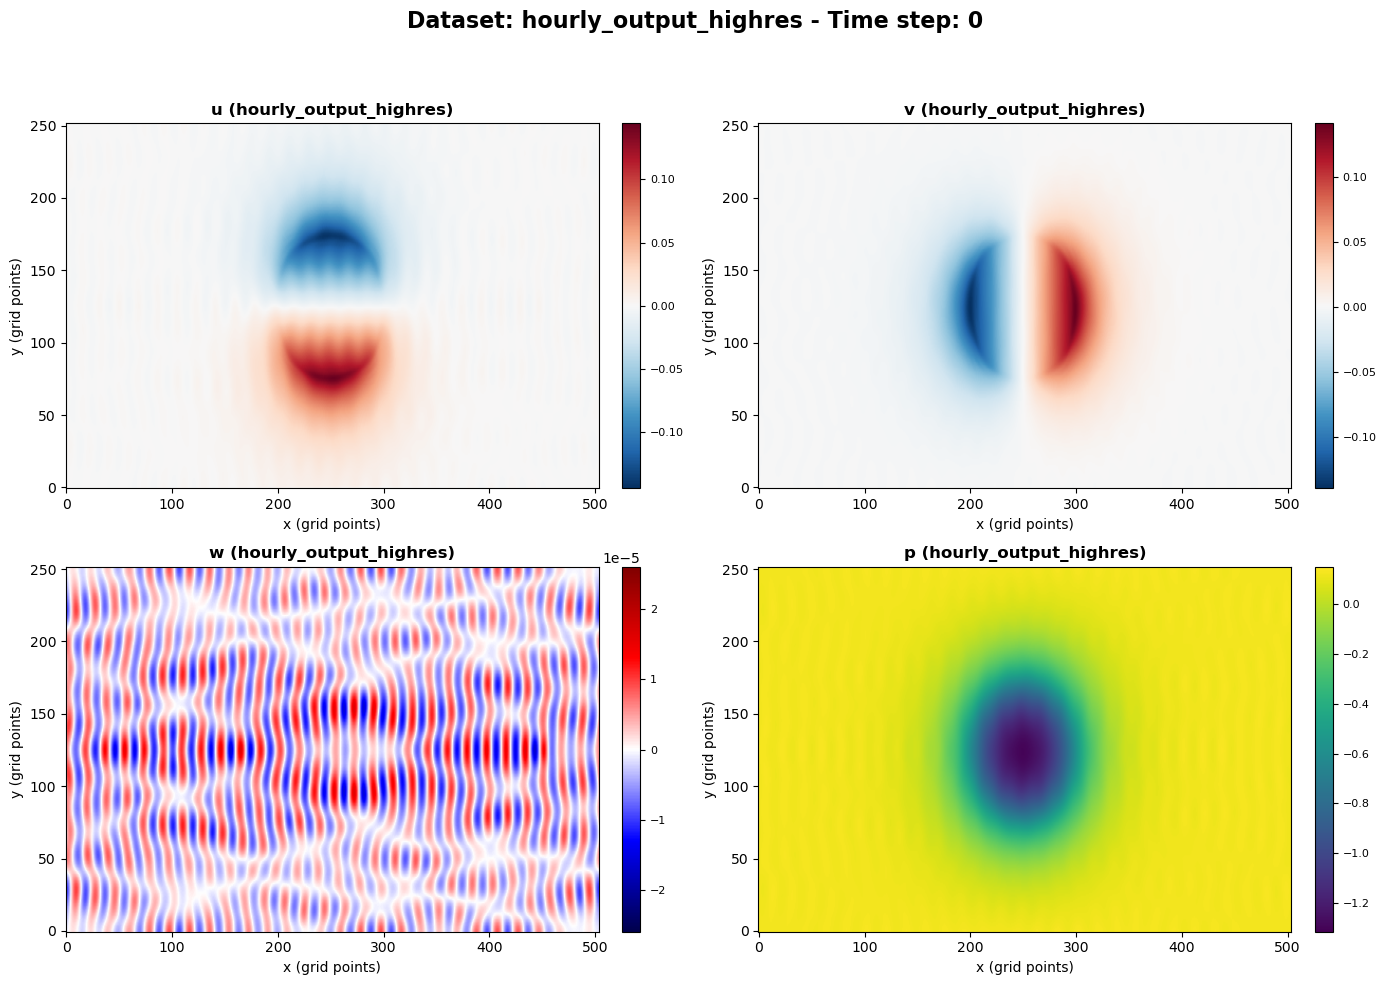

In [6]:
create_animation_for_dataset(ds_hourly_highres, 'hourly_output_highres', z_level=0)

In [9]:
# Band pass for internal tides
from scipy.signal import butter, lfilter

# cut off 
nyquist_freq = 1.0 / 2.0  # Nyquist frequency
#low_cutoff_freq = 1.0 / (15 )  
#high_cutoff_freq = 1.0 / (9 )  
low_cutoff_freq = 1.0 / (2.9)  ## here the unit is hour, that means you have hourly data
high_cutoff_freq = 1.0 / (2.6) 
# low_cutoff_freq = 1.0 / (9 )  
# high_cutoff_freq = 1.0 / (3 )
order = 2  # Filter order 


def butter_bandpass(lowcut, highcut, nyquist_freq, order=2):
    low = lowcut / nyquist_freq
    high = highcut / nyquist_freq
    b, a = butter(order, [low, high], btype='band', analog=False)
    return b, a

b2, a2 = butter_bandpass(low_cutoff_freq, high_cutoff_freq, nyquist_freq, order=order)



In [10]:
u = ds.u[:,0,:,:]
v = ds.v[:,0,:,:]
w = ds.w[:,0,:,:]
p = ds.p[:,0,:,:]

In [11]:


bpu = lfilter(b2, a2, u, axis=0)


In [12]:
bpv = lfilter(b2, a2, v, axis=0)


In [13]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Assuming bpu is your data array with shape (N, height, width)
# where N is the number of frames you want to animate through

def animate_array(data, interval=100, save_as=None, title_prefix="Frame"):
    """
    Create an animation cycling through all elements along the first dimension of any 3D array.
    
    Parameters:
    data : numpy.ndarray
        3D array with shape (N, height, width) - works with bpu, bpv, bpp, or any other array
    interval : int
        Delay between frames in milliseconds (default: 100)
    save_as : str, optional
        Filename to save animation (e.g., 'animation.gif' or 'animation.mp4')
    title_prefix : str
        Prefix for the frame title (default: "Frame")
    """
    
    # Input validation
    if len(data.shape) != 3:
        raise ValueError(f"Data must be 3D array, got shape {data.shape}")
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Get global min/max for consistent color scaling across all frames
    vmin, vmax = np.nanmin(data), np.nanmax(data)
    print(f"Data shape: {data.shape}")
    print(f"Data range: {vmin:.3f} to {vmax:.3f}")
    print(f"Animating {data.shape[0]} frames")
    
    # Initialize the plot with the first frame
    im = ax.imshow(data[0, :, :], cmap='RdBu_r', 
                   aspect='auto', origin='lower',
                   vmin=vmin, vmax=vmax)
    
    # Add colorbar
    cbar = plt.colorbar(im)
    
    # Set up the title to show current frame
    title = ax.set_title(f'{title_prefix} 0 / {data.shape[0]-1}')
    
    def animate(frame):
        """Animation function called for each frame"""
        im.set_data(data[frame, :, :])  # Use set_data instead of set_array
        title.set_text(f'{title_prefix} {frame} / {data.shape[0]-1}')
        return [im, title]
    
    # Create animation - disable blitting for better compatibility
    anim = animation.FuncAnimation(fig, animate, frames=data.shape[0],
                                 interval=interval, blit=False, repeat=True)
    
    # Save animation if filename provided
    if save_as:
        print(f"Saving animation as {save_as}...")
        if save_as.endswith('.gif'):
            anim.save(save_as, writer='pillow', fps=1000//interval)
        elif save_as.endswith('.mp4'):
            # Use matplotlib's default writer or specify ffmpeg
            try:
                anim.save(save_as, writer='ffmpeg', fps=1000//interval, bitrate=1800)
            except:
                # Fallback to default writer
                anim.save(save_as, fps=1000//interval, bitrate=1800)
        else:
            print("Unsupported format. Use .gif or .mp4")
        print("Animation saved!")
    
    plt.show()
    return anim




Data shape: (480, 252, 504)
Data range: -0.009 to 0.009
Animating 480 frames
Saving animation as animation_bpu_fix.mp4...
Animation saved!


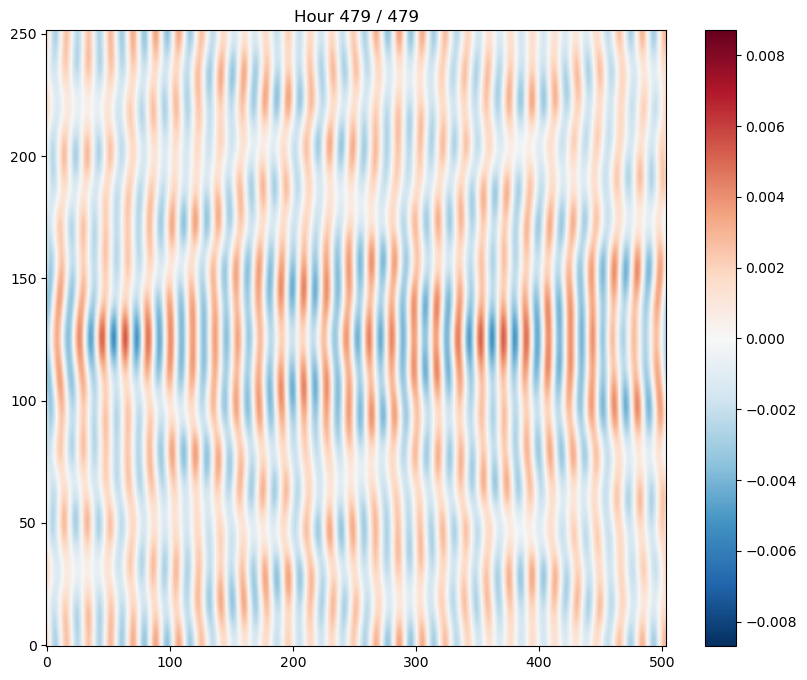

Data shape: (480, 252, 504)
Data range: -0.009 to 0.009
Animating 480 frames
Saving animation as animation_bpv_fix.mp4...
Animation saved!


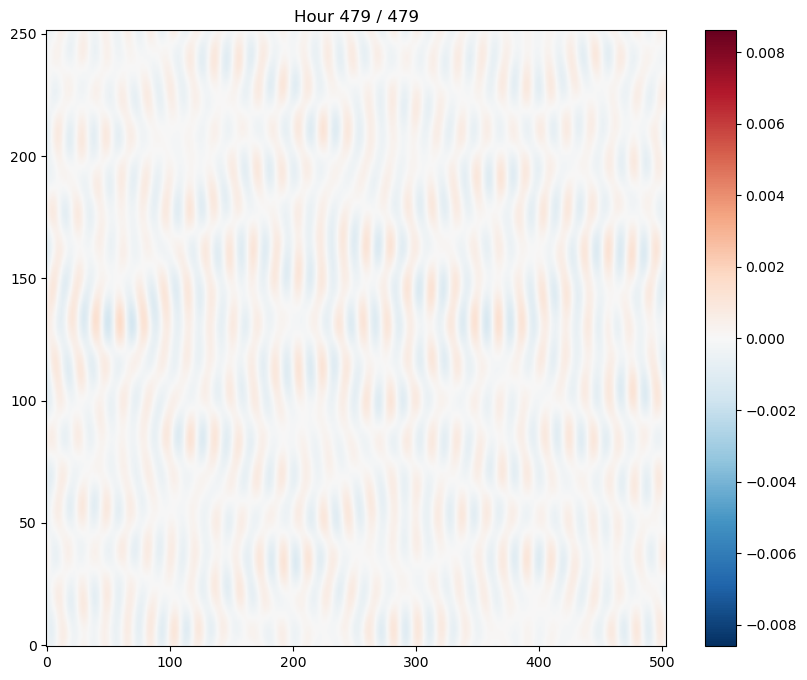

In [14]:
ani = animate_array(bpu, interval=150, save_as='animation_bpu_fix.mp4', title_prefix="Hour")
ani = animate_array(bpv, interval=150, save_as='animation_bpv_fix.mp4', title_prefix="Hour")

In [7]:



nyquist_freq = 1.0 / 2.0  # Nyquist frequency (half of the sampling frequency)
low_cutoff_freq = 1.0 / (62/24)  # High-pass cutoff frequency 
order = 2  # Filter order 

def butter_lowpass(lowcut, nyquist_freq, order=2):
    low = lowcut / nyquist_freq
    b, a = butter(order, low, btype='low', analog=False)
    return b, a

# low-pass filter
b2, a2 = butter_lowpass(low_cutoff_freq, nyquist_freq, order=order)



In [9]:
# Applying the low-pass filter
lpu4= lfilter(b2, a2, u,axis=0)
lpv4 = lfilter(b2, a2, v,axis=0)

Data shape: (240, 252, 504)
Data range: -0.238 to 0.239
Animating 240 frames
Saving animation as animation_lpu.mp4...
Animation saved!


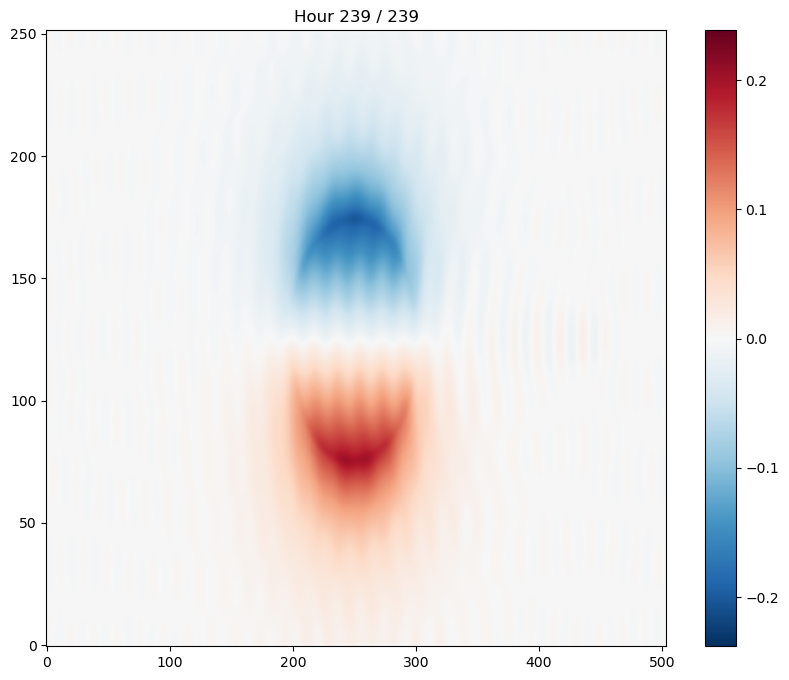

Data shape: (240, 252, 504)
Data range: -0.236 to 0.234
Animating 240 frames
Saving animation as animation_lpv.mp4...
Animation saved!


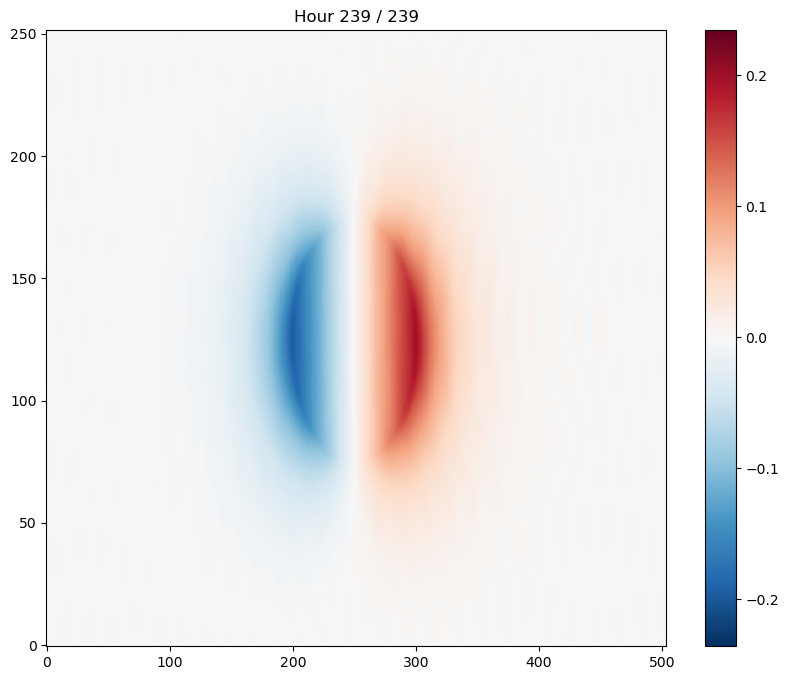

In [12]:
ani = animate_array(lpu4, interval=150, save_as='animation_lpu.mp4', title_prefix="Hour")
ani = animate_array(lpv4, interval=150, save_as='animation_lpv.mp4', title_prefix="Hour")

In [8]:
lpw4 = lfilter(b2, a2, w,axis=0)


Data shape: (240, 252, 504)
Data range: -0.000 to 0.000
Animating 240 frames
Saving animation as animation_lpw.mp4...
Animation saved!


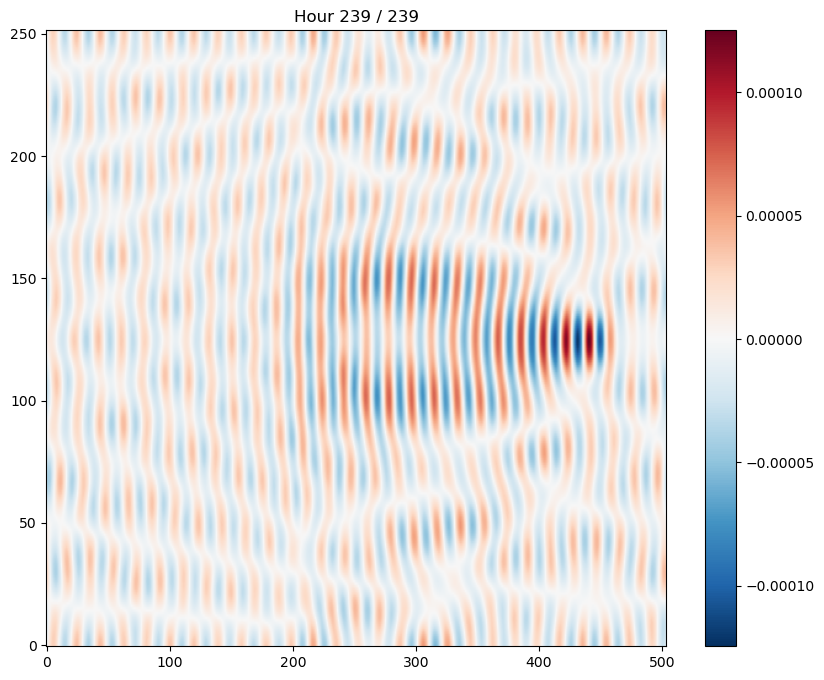

In [9]:
ani = animate_array(lpw4, interval=150, save_as='animation_lpw.mp4', title_prefix="Hour")

Data shape: (240, 252, 504)
Data range: -2.163 to 0.207
Animating 240 frames
Saving animation as animation_lpb.mp4...
Animation saved!


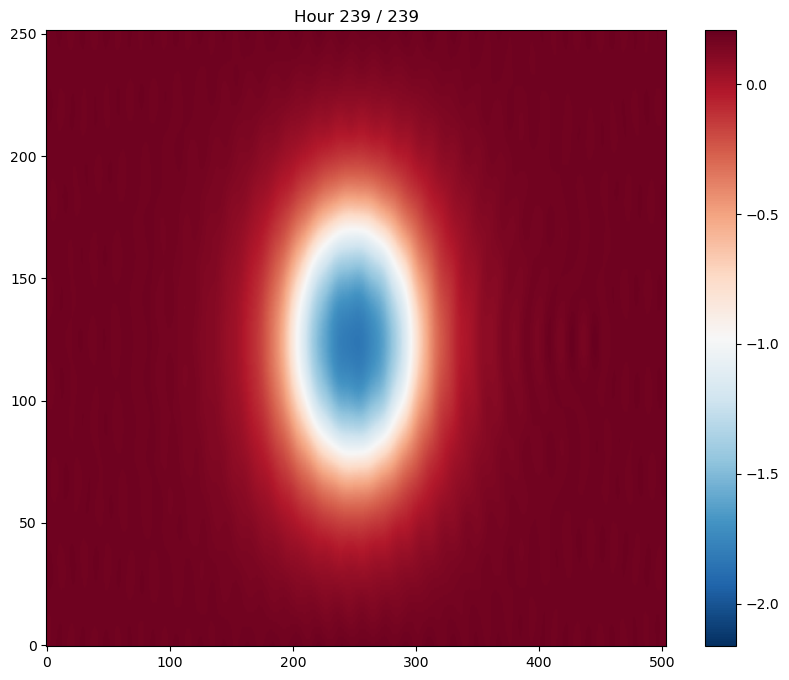

In [10]:
lpb4 = lfilter(b2, a2, p,axis=0)
ani = animate_array(lpb4, interval=150, save_as='animation_lpb.mp4', title_prefix="Hour")

Data shape: (240, 252, 504)
Data range: -0.307 to 0.325
Animating 240 frames
Saving animation as animation_bpp.mp4...
Animation saved!


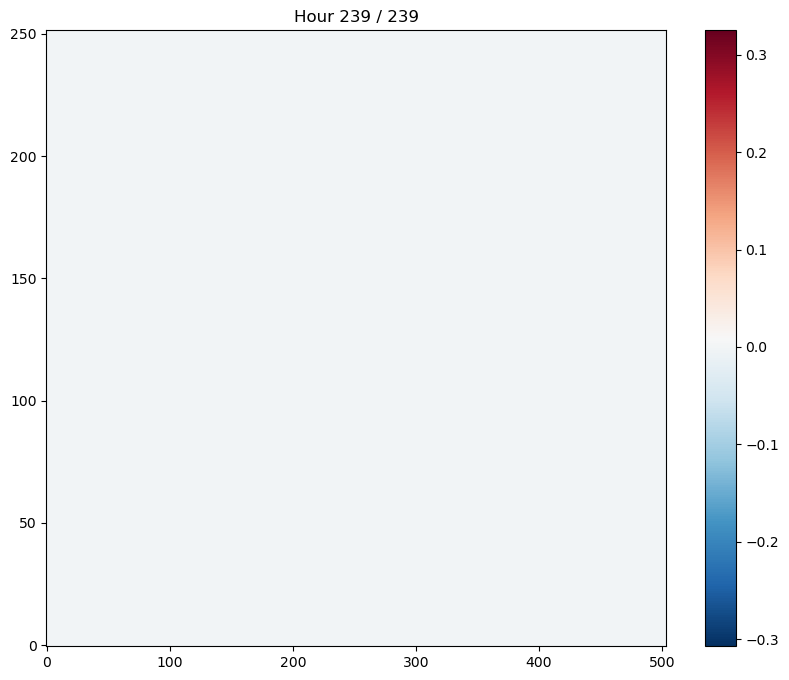

In [8]:
bpp = lfilter(b2, a2, p, axis=0)
ani = animate_array(bpp, interval=150, save_as='animation_bpp.mp4', title_prefix="Hour")

Data shape: (240, 252, 504)
Data range: -0.000 to 0.000
Animating 240 frames
Saving animation as animation_bpw.mp4...
Animation saved!


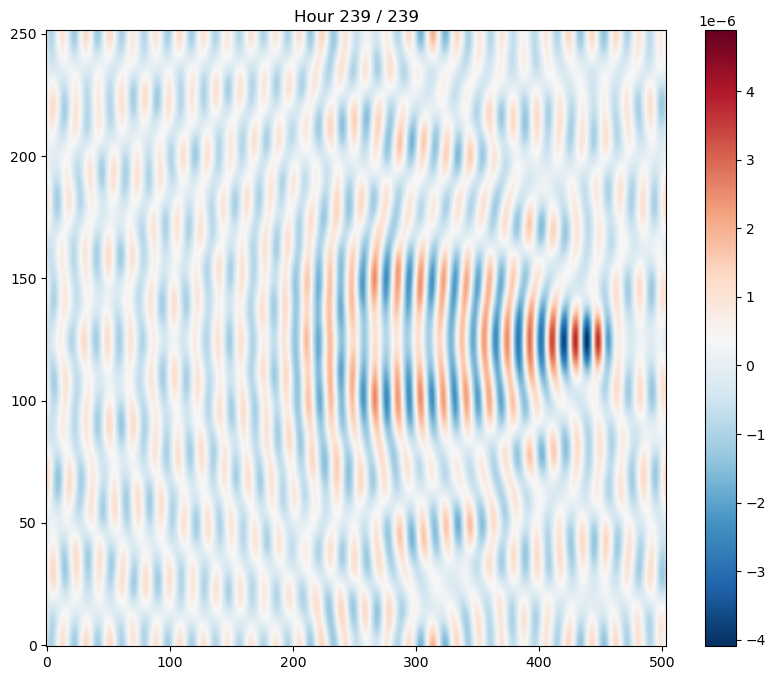

In [9]:
bpw = lfilter(b2, a2, w, axis=0)
ani = animate_array(bpw, interval=150, save_as='animation_bpw.mp4', title_prefix="Hour")

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os

def calculate_derived_variables(dataset, z, time_step=0, reference_density=1025.0, g=9.81):
    """
    Calculate derived variables from the dataset
    
    Parameters:
    -----------
    dataset : xarray.Dataset
        Input dataset
    z : array-like
        Depth/height coordinates
    time_step : int
        Time step to use for calculations
    reference_density : float
        Reference density for buoyancy calculations (kg/m³)
    g : float
        Gravitational acceleration (m/s²)
    
    Returns:
    --------
    dict : Dictionary of derived variables with their profiles
    """
    
    derived_vars = {}
    
    # Get spatial dimensions (assuming last two are horizontal)
    if len(list(dataset.data_vars.values())[0].shape) >= 3:
        # Average over horizontal dimensions for profiles
        spatial_dims = (-2, -1)  # last two dimensions (y, x)
    else:
        spatial_dims = None
    
    try:
        # Density from buoyancy
        if 'b' in dataset:
            b_data = dataset['b']
            if len(b_data.shape) == 4:  # (time, z, y, x)
                b_profile = np.nanmean(b_data[time_step, :, :, :], axis=(1, 2))
            elif len(b_data.shape) == 3:  # (z, y, x)
                b_profile = np.nanmean(b_data[:, :, :], axis=(1, 2))
            else:
                b_profile = b_data[:]
            
            # Convert buoyancy to density: ρ = ρ₀ * (1 - b/g)
            density = - reference_density *  b_profile / g
            derived_vars['density'] = density
        
        # Brunt-Väisälä frequency squared (N²)
        if 'b' in dataset and len(z) > 1:
            N2 = np.zeros_like(b_profile)
            
            # Central differences for interior points
            for i in range(1, len(b_profile) - 1):
                dz_up = z[i] - z[i-1]
                dz_down = z[i+1] - z[i]
                if dz_up > 0 and dz_down > 0:
                    N2[i] = -(b_profile[i+1] - b_profile[i-1]) / (dz_up + dz_down)
            
            # Boundaries
            if len(z) > 1:
                N2[0] = -(b_profile[1] - b_profile[0]) / (z[1] - z[0]) if z[1] != z[0] else 0
                N2[-1] = -(b_profile[-1] - b_profile[-2]) / (z[-1] - z[-2]) if z[-1] != z[-2] else 0
            
            derived_vars['N2'] = N2
        
        # Kinetic Energy
        if 'u' in dataset and 'v' in dataset:
            u_data = dataset['u']
            v_data = dataset['v']
            
            if len(u_data.shape) == 4:  # (time, z, y, x)
                u_profile = np.nanmean(u_data[time_step, :, :, :], axis=spatial_dims)
                v_profile = np.nanmean(v_data[time_step, :, :, :], axis=spatial_dims)
            else:
                u_profile = np.nanmean(u_data, axis=spatial_dims) if spatial_dims else u_data[:]
                v_profile = np.nanmean(v_data, axis=spatial_dims) if spatial_dims else v_data[:]
            
            # Add w component if available
            if 'w' in dataset:
                w_data = dataset['w']
                if len(w_data.shape) == 4:
                    w_profile = np.nanmean(w_data[time_step, :, :, :], axis=spatial_dims)
                else:
                    w_profile = np.nanmean(w_data, axis=spatial_dims) if spatial_dims else w_data[:]
                ke = 0.5 * (u_profile**2 + v_profile**2 + w_profile**2)
            else:
                ke = 0.5 * (u_profile**2 + v_profile**2)
            
            derived_vars['kinetic_energy'] = ke
        
        # Horizontal velocity magnitude
        if 'u' in dataset and 'v' in dataset:
            u_data = dataset['u']
            v_data = dataset['v']
            
            if len(u_data.shape) == 4:
                u_profile = np.nanmean(u_data[time_step, :, :, :], axis=spatial_dims)
                v_profile = np.nanmean(v_data[time_step, :, :, :], axis=spatial_dims)
            else:
                u_profile = np.nanmean(u_data, axis=spatial_dims) if spatial_dims else u_data[:]
                v_profile = np.nanmean(v_data, axis=spatial_dims) if spatial_dims else v_data[:]
            
            vel_magnitude = np.sqrt(u_profile**2 + v_profile**2)
            derived_vars['horizontal_velocity'] = vel_magnitude
        
        # Potential Energy Anomaly (if density is available)
        """if 'density' in derived_vars:
            rho = derived_vars['density']
            # Simple potential energy anomaly: g * ∫(ρ - ρ_ref) dz
            pe_anomaly = np.zeros_like(rho)
            for i in range(len(rho)):
                if i > 0:
                    dz = z[i] - z[i-1] if len(z) > i else 1.0
                    pe_anomaly[i] = pe_anomaly[i-1] + g * (rho[i] - reference_density) * dz
            derived_vars['potential_energy_anomaly'] = pe_anomaly"""
            
    except Exception as e:
        print(f"Warning: Error calculating derived variables: {e}")
    
    return derived_vars

def create_vertical_profile_animation(dataset, dataset_name, save_animation=True):
    """
    Create vertical profile animation for a single dataset showing profiles across z-levels
    
    Parameters:
    -----------
    dataset : xarray.Dataset
        Input dataset
    dataset_name : str
        Name of the dataset for labeling
    save_animation : bool
        Whether to save animation files
    
    Returns:
    --------
    tuple : (animation, figure) objects
    """
    
    # Define primary variables to plot
    primary_variables = ['u', 'v', 'w', 'p', 'b']
    
    # Get z coordinate
    z = None
    for z_name in ['z', 'depth', 'lev', 'level']:
        if z_name in dataset.coords:
            z = dataset[z_name].values
            break
        elif z_name in dataset.dims:
            z = np.arange(dataset.dims[z_name])
            break
    
    if z is None:
        print(f"Error: No vertical coordinate found for dataset {dataset_name}")
        return None, None
    
    # Determine number of time steps
    time_dim = None
    for var in primary_variables:
        if var in dataset:
            if 'Time' in dataset[var].dims:
                time_dim = 'Time'
            elif 't' in dataset[var].dims:
                time_dim = 't'
            break
    
    if time_dim:
        t_levels = dataset.dims[time_dim]
    else:
        t_levels = 1
        print(f"Warning: No time dimension found, creating single frame")
    
    # Get available primary variables
    available_vars = [var for var in primary_variables if var in dataset]
    
    if not available_vars:
        print(f"Error: No recognized variables found in dataset {dataset_name}")
        return None, None
    
    # Calculate derived variables for the first time step to get available ones
    derived_vars = calculate_derived_variables(dataset, z, time_step=0)
    derived_var_names = list(derived_vars.keys())
    
    # Combine all variables
    all_variables = available_vars + derived_var_names
    n_vars = len(all_variables)
    
    # Calculate subplot layout
    n_cols = min(3, n_vars)  # Maximum 3 columns
    n_rows = int(np.ceil(n_vars / n_cols))
    
    # Create figure and subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_vars == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if hasattr(axes, '__len__') else [axes]
    else:
        axes = axes.flatten()
    
    # Hide extra subplots
    for i in range(n_vars, len(axes)):
        axes[i].set_visible(False)
    
    # Initialize plot lines and set up axes
    lines = []
    variable_info = {}
    
    for i, var in enumerate(all_variables):
        ax = axes[i]
        
        # Create line object
        line, = ax.plot([], [], 'b-', linewidth=2, alpha=0.8)
        lines.append(line)
        
        # Set up axes
        ax.set_ylim(z[0], z[-1])
        ax.invert_yaxis()  # Depth increases downward
        ax.set_ylabel('Depth/Height', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Variable-specific formatting
        if var in ['u', 'v']:
            ax.set_xlabel('Velocity (m/s)', fontsize=10)
            ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
            color = 'blue' if var == 'u' else 'red'
            line.set_color(color)
        elif var == 'w':
            ax.set_xlabel('Vertical Velocity (m/s)', fontsize=10)
            ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
            line.set_color('green')
        elif var == 'p':
            ax.set_xlabel('Pressure', fontsize=10)
            line.set_color('purple')
        elif var == 'b':
            ax.set_xlabel('Buoyancy (m/s²)', fontsize=10)
            ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
            line.set_color('orange')
        elif var == 'density':
            ax.set_xlabel('Density (kg/m³)', fontsize=10)
            line.set_color('brown')
        elif var == 'N2':
            ax.set_xlabel('N² (s⁻²)', fontsize=10)
            ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
            line.set_color('darkred')
        elif var == 'kinetic_energy':
            ax.set_xlabel('Kinetic Energy (m²/s²)', fontsize=10)
            line.set_color('darkgreen')
        elif var == 'horizontal_velocity':
            ax.set_xlabel('|U| (m/s)', fontsize=10)
            line.set_color('cyan')
        else:
            ax.set_xlabel(f'{var}', fontsize=10)
            line.set_color('black')
        
        ax.set_title(f'{var.replace("_", " ").title()}', fontsize=12, fontweight='bold')
        
        # Store variable info for later use
        variable_info[var] = {'index': i, 'primary': var in available_vars}
    
    plt.tight_layout()
    fig.suptitle(f'Vertical Profiles - {dataset_name} - Time: 0', fontsize=16, fontweight='bold')
    plt.subplots_adjust(top=0.93)
    
    # Pre-compute all profiles for consistent scaling
    all_profiles = {}
    for var in all_variables:
        all_profiles[var] = []
    
    print(f"Pre-computing profiles for {t_levels} time steps...")
    for t in range(min(t_levels, 10)):  # Sample subset for scaling
        # Get primary variable profiles
        for var in available_vars:
            try:
                if time_dim and t < dataset.dims[time_dim]:
                    if len(dataset[var].shape) == 4:  # (time, z, y, x)
                        profile = np.nanmean(dataset[var][t, :, :, :], axis=(1, 2))
                    elif len(dataset[var].shape) == 3:  # (z, y, x) - no time
                        profile = np.nanmean(dataset[var][:, :, :], axis=(1, 2))
                    else:
                        profile = dataset[var][:]
                else:
                    # No time dimension or single time step
                    if len(dataset[var].shape) >= 3:
                        profile = np.nanmean(dataset[var], axis=(-2, -1))
                    else:
                        profile = dataset[var][:]
                
                all_profiles[var].append(profile)
            except Exception as e:
                print(f"Error processing {var} at time {t}: {e}")
                all_profiles[var].append(np.zeros_like(z))
        
        # Get derived variable profiles
        derived_vars = calculate_derived_variables(dataset, z, time_step=t)
        for var in derived_var_names:
            if var in derived_vars:
                all_profiles[var].append(derived_vars[var])
            else:
                all_profiles[var].append(np.zeros_like(z))
    
    # Set axis limits based on computed profiles
    for var, profiles in all_profiles.items():
        if profiles:
            all_values = np.concatenate([p for p in profiles if len(p) > 0])
            if len(all_values) > 0 and not np.all(np.isnan(all_values)):
                vmin, vmax = np.nanmin(all_values), np.nanmax(all_values)
                if vmin != vmax:
                    margin = 10 * (vmax - vmin)
                    axes[variable_info[var]['index']].set_xlim(vmin - margin, vmax + margin)
                else:
                    axes[variable_info[var]['index']].set_xlim(vmin - 1, vmax + 1)
    
    def update(frame):
        """Update function for animation"""
        
        # Get primary variable profiles
        current_profiles = {}
        for var in available_vars:
            try:
                if time_dim and frame < dataset.dims[time_dim]:
                    if len(dataset[var].shape) == 4:  # (time, z, y, x)
                        profile = np.nanmean(dataset[var][frame, :, :, :], axis=(1, 2))
                    elif len(dataset[var].shape) == 3:  # (z, y, x) - no time
                        profile = np.nanmean(dataset[var][:, :, :], axis=(1, 2))
                    else:
                        profile = dataset[var][:]
                else:
                    if len(dataset[var].shape) >= 3:
                        profile = np.nanmean(dataset[var], axis=(-2, -1))
                    else:
                        profile = dataset[var][:]
                
                current_profiles[var] = profile
            except Exception as e:
                print(f"Error updating {var} at frame {frame}: {e}")
                current_profiles[var] = np.zeros_like(z)
        
        # Get derived variable profiles
        derived_vars = calculate_derived_variables(dataset, z, time_step=frame)
        current_profiles.update(derived_vars)
        
        # Update lines
        updated_artists = []
        for var in all_variables:
            if var in current_profiles:
                line_idx = variable_info[var]['index']
                profile = current_profiles[var]
                if len(profile) == len(z):
                    lines[line_idx].set_data(profile, z)
                else:
                    lines[line_idx].set_data([], [])
                updated_artists.append(lines[line_idx])
        
        fig.suptitle(f'Vertical Profiles - {dataset_name} - Time: {frame}', 
                    fontsize=16, fontweight='bold')
        
        return updated_artists
    
    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=t_levels, 
                                 interval=200, blit=False, repeat=True)
    
    if save_animation:
        # Create output directory
        output_dir = 'fig_idealized'
        os.makedirs(output_dir, exist_ok=True)
        
        
        # Save as MP4
        try:
            mp4_filename = os.path.join(output_dir, f'vertical_profiles_{dataset_name}.mp4')
            ani.save(mp4_filename, writer='ffmpeg', fps=5, bitrate=1800)
            print(f"Saved vertical profile MP4: {mp4_filename}")
        except Exception as e:
            print(f"Could not save MP4 for {dataset_name}: {e}")
    
    return ani, fig

/tmp/ipykernel_653812/1070728905.py:172: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  t_levels = dataset.dims[time_dim]


Pre-computing profiles for 240 time steps...


/tmp/ipykernel_653812/1070728905.py:279: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if time_dim and t < dataset.dims[time_dim]:
/tmp/ipykernel_653812/1070728905.py:325: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if time_dim and frame < dataset.dims[time_dim]:


Saved vertical profile MP4: fig_idealized/vertical_profiles_hourly.mp4


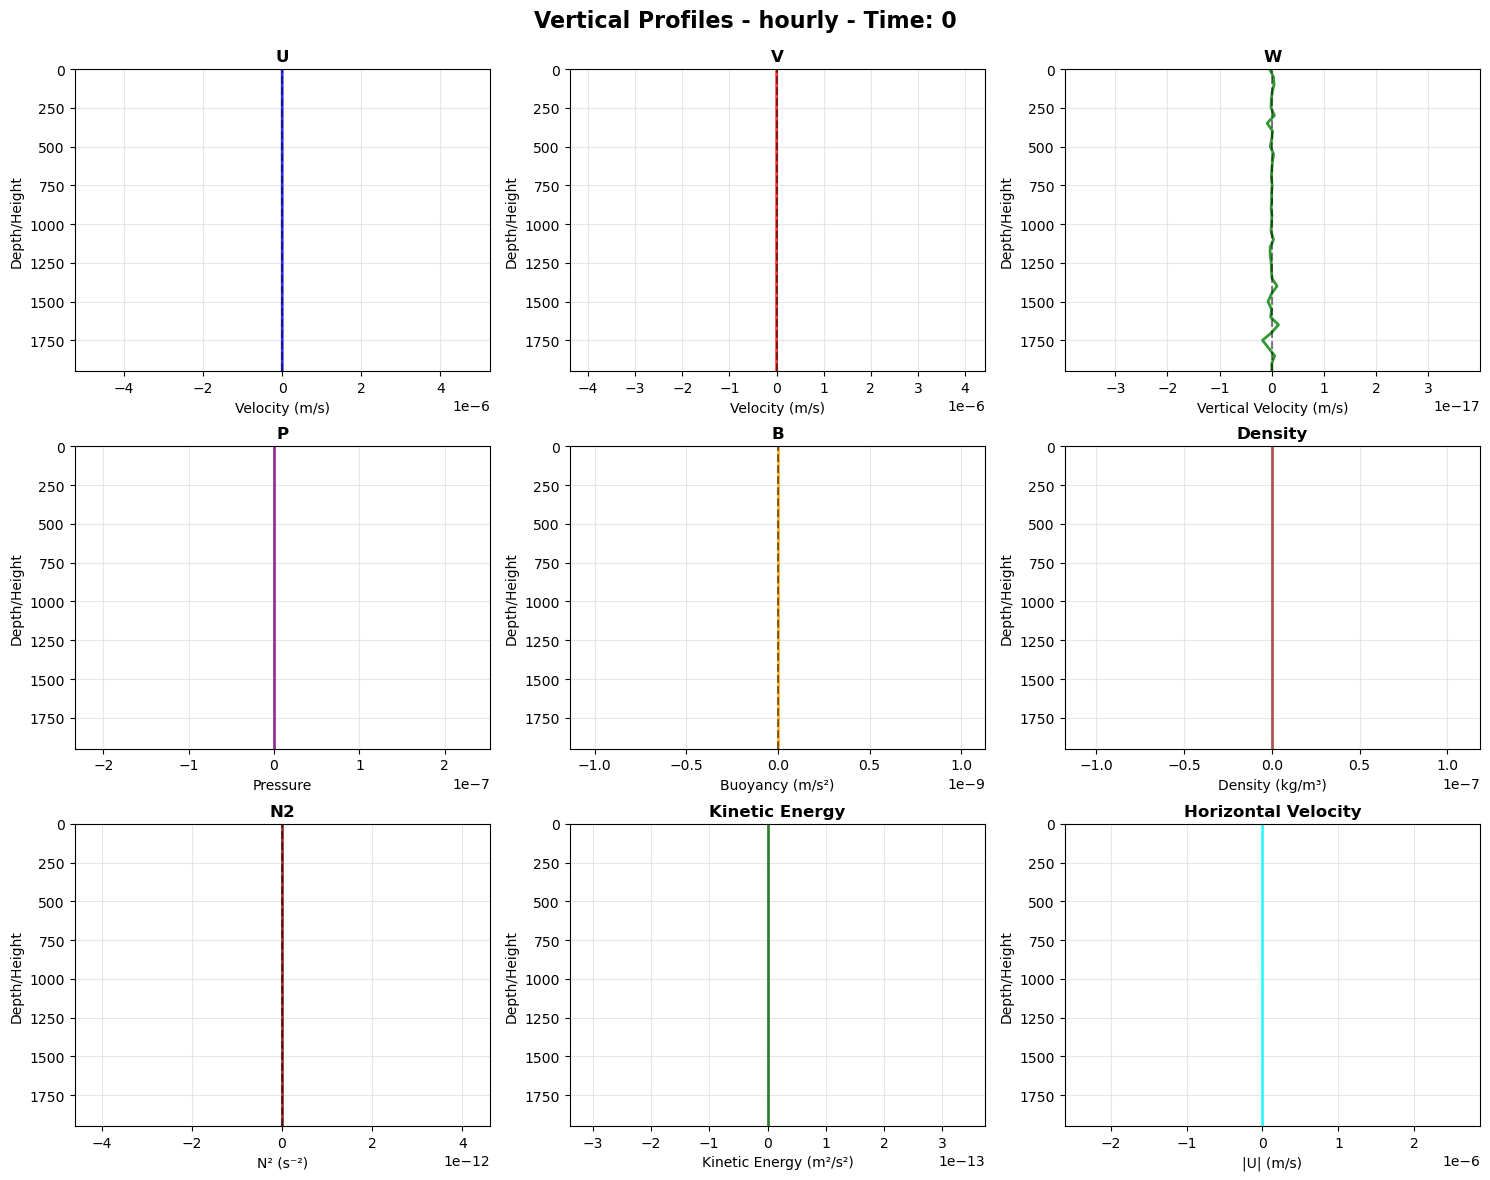

In [6]:
ani, fig = create_vertical_profile_animation(ds_hourly, 'hourly')


In [7]:
b_mod = ds_hourly['b'] - np.nanmean(ds_hourly['b'], axis=(1,2,3), keepdims=True)
np.min(b_mod), np.max(b_mod)

: 